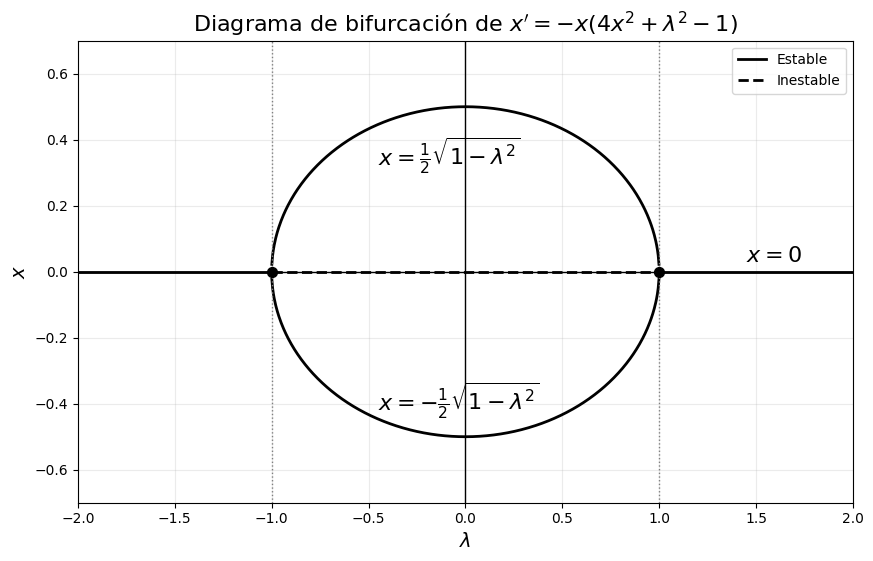

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Rango del parámetro lambda
# ----------------------------
lam = np.linspace(-2, 2, 1000)

# Rama x = 0
x0 = np.zeros_like(lam)

# Zonas donde existen las otras ramas
mask = np.abs(lam) <= 1
lam_central = lam[mask]

# Ramas no triviales
x_plus = 0.5 * np.sqrt(1 - lam_central**2)
x_minus = -0.5 * np.sqrt(1 - lam_central**2)

# ----------------------------
# Gráfico
# ----------------------------
plt.figure(figsize=(10, 6))

# Rama x = 0
# estable para |lambda| > 1
mask_left = lam < -1
mask_right = lam > 1
mask_unstable = (lam > -1) & (lam < 1)

plt.plot(lam[mask_left], x0[mask_left], color='black', linewidth=2, label='Estable')
plt.plot(lam[mask_right], x0[mask_right], color='black', linewidth=2)

# inestable para |lambda| < 1
plt.plot(lam[mask_unstable], x0[mask_unstable],
         color='black', linestyle='--', linewidth=2, label='Inestable')

# Ramas estables x = ± sqrt(1-lambda^2)/2
plt.plot(lam_central, x_plus, color='black', linewidth=2)
plt.plot(lam_central, x_minus, color='black', linewidth=2)

# Puntos de bifurcación
plt.scatter([-1, 1], [0, 0], color='black', s=50, zorder=5)

# Líneas guía en lambda = -1 y lambda = 1
plt.axvline(-1, color='gray', linestyle=':', linewidth=1)
plt.axvline(1, color='gray', linestyle=':', linewidth=1)

# Ejes coordenados
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Etiquetas de ramas
plt.text(1.45, 0.03, r'$x=0$', fontsize=16)
plt.text(-0.45, 0.60/2 + 0.02, r'$x=\frac{1}{2}\sqrt{1-\lambda^2}$', fontsize=16)
plt.text(-0.45, -0.60/2 - 0.12, r'$x=-\frac{1}{2}\sqrt{1-\lambda^2}$', fontsize=16)

# Formato
plt.title(r"Diagrama de bifurcación de $x'=-x(4x^2+\lambda^2-1)$", fontsize=16)
plt.xlabel(r'$\lambda$', fontsize=14)
plt.ylabel(r'$x$', fontsize=14)
plt.xlim(-2, 2)
plt.ylim(-0.7, 0.7)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

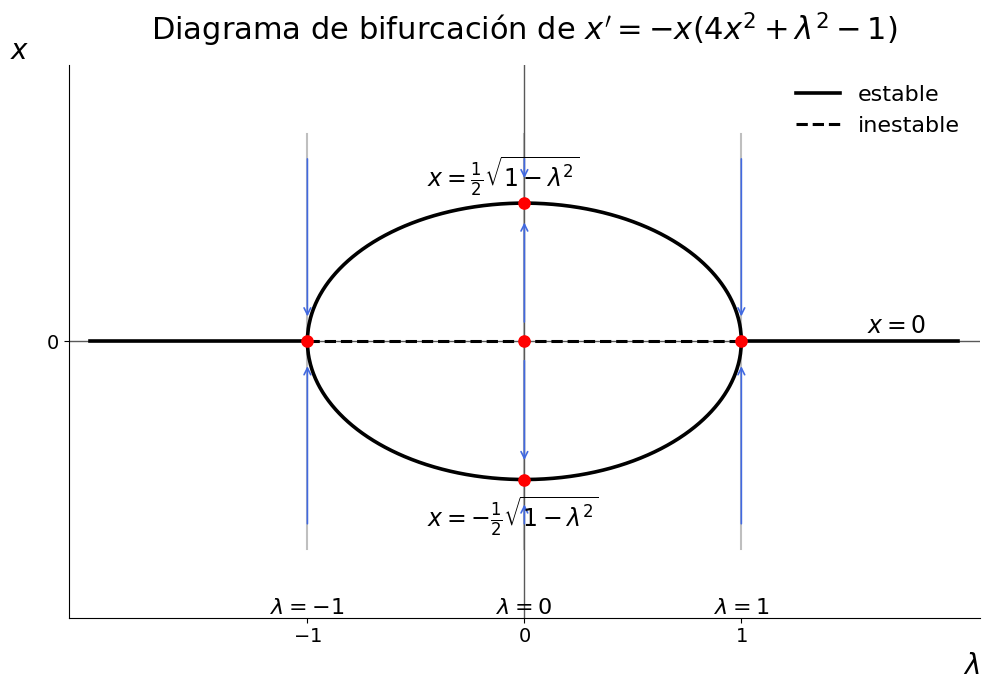

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Diagrama de bifurcación de x' = -x(4x^2 + lambda^2 - 1)
# =========================================================

def add_vertical_arrow(ax, x0, y_start, y_end, color='royalblue', lw=1.2):
    """Dibuja una flecha vertical desde y_start hasta y_end."""
    ax.annotate(
        '',
        xy=(x0, y_end),
        xytext=(x0, y_start),
        arrowprops=dict(arrowstyle='->', color=color, lw=lw, mutation_scale=12)
    )

def draw_phase_line_one_eq(ax, lam0, y_eq=0.0, y_min=-0.75, y_max=0.75,
                           line_color='0.75', arrow_color='royalblue',
                           point_color='red'):
    """
    Recta de fase con un único equilibrio estable en y_eq.
    """
    ax.plot([lam0, lam0], [y_min, y_max], color=line_color, lw=1.5, zorder=0)
    ax.scatter([lam0], [y_eq], color=point_color, s=65, zorder=6)

    # flecha inferior hacia arriba
    add_vertical_arrow(ax, lam0, y_min + 0.08, y_eq - 0.08,
                       color=arrow_color)

    # flecha superior hacia abajo
    add_vertical_arrow(ax, lam0, y_max - 0.08, y_eq + 0.08,
                       color=arrow_color)

def draw_phase_line_three_eq(ax, lam0, a, y_min=-0.75, y_max=0.75,
                             line_color='0.75', arrow_color='royalblue',
                             point_color='red'):
    """
    Recta de fase con tres equilibrios: -a, 0, a.
    Para este sistema:
      x < -a      -> flecha hacia arriba
      -a < x < 0  -> flecha hacia abajo
      0 < x < a   -> flecha hacia arriba
      x > a       -> flecha hacia abajo
    """
    ax.plot([lam0, lam0], [y_min, y_max], color=line_color, lw=1.5, zorder=0)
    ax.scatter([lam0, lam0, lam0], [-a, 0, a], color=point_color, s=65, zorder=6)

    # x < -a : hacia arriba
    add_vertical_arrow(ax, lam0, y_min + 0.08, -a - 0.08, color=arrow_color)

    # -a < x < 0 : hacia abajo
    add_vertical_arrow(ax, lam0, -0.06, -a + 0.06, color=arrow_color)

    # 0 < x < a : hacia arriba
    add_vertical_arrow(ax, lam0, 0.06, a - 0.06, color=arrow_color)

    # x > a : hacia abajo
    add_vertical_arrow(ax, lam0, y_max - 0.08, a + 0.08, color=arrow_color)


# ---------------------------------------------------------
# Datos de las ramas de equilibrio
# ---------------------------------------------------------
lam = np.linspace(-2, 2, 1200)
x0 = np.zeros_like(lam)

mask_center = np.abs(lam) <= 1
lam_center = lam[mask_center]

x_plus = 0.5 * np.sqrt(1 - lam_center**2)
x_minus = -0.5 * np.sqrt(1 - lam_center**2)

mask_left = lam < -1
mask_right = lam > 1
mask_unstable = (lam > -1) & (lam < 1)

# ---------------------------------------------------------
# Figura
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 7))

# Rama x = 0 estable para |lambda| > 1
ax.plot(lam[mask_left], x0[mask_left], color='black', lw=2.6,
        label='estable', zorder=3)
ax.plot(lam[mask_right], x0[mask_right], color='black', lw=2.6,
        zorder=3)

# Rama x = 0 inestable para |lambda| < 1
ax.plot(lam[mask_unstable], x0[mask_unstable], color='black',
        lw=2.2, ls='--', label='inestable', zorder=3)

# Ramas estables no triviales
ax.plot(lam_center, x_plus, color='black', lw=2.6, zorder=3)
ax.plot(lam_center, x_minus, color='black', lw=2.6, zorder=3)

# ---------------------------------------------------------
# Rectas de fase EXACTAMENTE en lambda = -1, 0, 1
# ---------------------------------------------------------
draw_phase_line_one_eq(ax, -1.0)
draw_phase_line_three_eq(ax, 0.0, a=0.5)
draw_phase_line_one_eq(ax, 1.0)

# ---------------------------------------------------------
# Ejes
# ---------------------------------------------------------
ax.axhline(0, color='0.35', lw=1.0, zorder=1)
ax.axvline(0, color='0.35', lw=1.0, zorder=1)

# Sacar bordes de arriba y derecha
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ---------------------------------------------------------
# Etiquetas
# ---------------------------------------------------------
ax.text(1.58, 0.03, r'$x=0$', fontsize=17)
ax.text(-0.45, 0.56, r'$x=\frac{1}{2}\sqrt{1-\lambda^2}$', fontsize=17)
ax.text(-0.45, -0.67, r'$x=-\frac{1}{2}\sqrt{1-\lambda^2}$', fontsize=17)

# Etiquetas debajo de las rectas
ax.text(-1.0, -0.93, r'$\lambda=-1$', ha='center', va='top', fontsize=16)
ax.text(0.0, -0.93, r'$\lambda=0$', ha='center', va='top', fontsize=16)
ax.text(1.0, -0.93, r'$\lambda=1$', ha='center', va='top', fontsize=16)

# Ticks
ax.set_xticks([-1, 0, 1])
ax.set_xticklabels([r'$-1$', r'$0$', r'$1$'], fontsize=14)

ax.set_yticks([0])
ax.set_yticklabels([r'$0$'], fontsize=14)

# Límites
ax.set_xlim(-2.1, 2.1)
ax.set_ylim(-1.0, 1.0)

# Título
ax.set_title(r"Diagrama de bifurcación de $x'=-x(4x^2+\lambda^2-1)$",
             fontsize=22, pad=18)

# Ejes
ax.set_xlabel(r'$\lambda$', fontsize=20, loc='right')
ax.set_ylabel(r'$x$', fontsize=20, rotation=0, labelpad=12, loc='top')

# Leyenda
ax.legend(frameon=False, fontsize=16, loc='upper right')

plt.tight_layout()
plt.show()